In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [8]:
path = "../../data/processed/tel_preprocessed_ver2.csv"
df = pd.read_csv(path)

print(df.shape)
print(df.info())
print(df[["id","year"]].head())

df = df.sort_values(["id","year"]).reset_index(drop=True)
df.head()

(34776, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34776 entries, 0 to 34775
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  34776 non-null  int64 
 1   gender              34776 non-null  int64 
 2   birth_year          34776 non-null  int64 
 3   mar                 34776 non-null  int64 
 4   income              34776 non-null  int64 
 5   job                 34776 non-null  int64 
 6   region              34776 non-null  int64 
 7   phone_usage_per_m   34776 non-null  int64 
 8   mobile_bundle       34776 non-null  int64 
 9   telecom             34776 non-null  int64 
 10  year                34776 non-null  int64 
 11  telcom_changed      34776 non-null  int64 
 12  churn_status_2      34776 non-null  object
 13  churn_status_num_2  34776 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 3.7+ MB
None
      id  year
0  10002  2017
1  10002  2018
2  10002  

,id,gender,birth_year,mar,income,job,region,phone_usage_per_m,mobile_bundle,telecom,year,telcom_changed,churn_status_2,churn_status_num_2
0,10002,1,1972,2,1,0,1,3,0,1,2017,0,SKT_stay,1
1,10002,1,1972,2,1,0,1,4,1,1,2018,0,SKT_stay,1
2,10002,1,1972,2,1,0,1,6,1,1,2019,0,SKT_stay,1
3,10002,1,1972,2,1,0,1,4,1,2,2020,1,SKT_churned,10
4,10002,1,1972,2,1,0,1,4,1,2,2021,0,KT_stay,2


In [9]:
df.head()
df.columns

Index(['id', 'gender', 'birth_year', 'mar', 'income', 'job', 'region',
       'phone_usage_per_m', 'mobile_bundle', 'telecom', 'year',
       'telcom_changed', 'churn_status_2', 'churn_status_num_2'],
      dtype='object')

In [10]:
# 데이터 정렬
df = df.sort_values(["id", "year"]).reset_index(drop=True)

# 소득 변화 여부
df["income_diff"] = (
    df.groupby("id")["income"]
      .diff()
      .fillna(0)
)

# 월평균 휴대폰 이용 총 금액 변화량
df["usage_diff"] = (
    df.groupby("id")["phone_usage_per_m"]
      .diff()
      .fillna(0)
)

In [11]:
drop_cols = ["id","year","school","telcom_changed","telecom","telecom_change_2yr","prev_telecom","churn_status_1","churn_status_num_1","churn_status_2","churn_status_num_2"]
features = [c for c in df.columns if c not in drop_cols]
target = "telcom_changed"
df[target] = df[target].fillna(0).astype(int)
X = df[features]
y = df[target]

In [12]:
features

['gender',
 'birth_year',
 'mar',
 'income',
 'job',
 'region',
 'phone_usage_per_m',
 'mobile_bundle',
 'income_diff',
 'usage_diff']

In [13]:
from sklearn.model_selection import GroupShuffleSplit

# 패널 데이터라서 id 기준으로 그룹화해서 분할해야 함 = train_test_split이 아닌 GrupShuffleSplit 사용
gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["id"]))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report
)

def evaluate_binary(model, X_test, y_test, name="model", threshold=0.5, show_plots=False):
    # 확률 예측
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # decision_function을 0~1로 변환 (단순 시그모이드)
        scores = model.decision_function(X_test)
        proba = 1 / (1 + np.exp(-scores))
    else:
        # 확률 불가 모델
        proba = None

    # 클래스 예측
    if proba is not None:
        pred = (proba >= threshold).astype(int)
    else:
        pred = model.predict(X_test)

    # 지표 계산
    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    }

    if proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, proba)
        metrics["pr_auc"] = average_precision_score(y_test, proba)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    print(f"\n=== {name} (threshold={threshold}) ===")
    print(pd.Series(metrics).round(4))
    print("\n[Classification Report]")
    print(classification_report(y_test, pred, digits=4))

    # 혼동행렬
    if show_plots:
        cm = confusion_matrix(y_test, pred)
        ConfusionMatrixDisplay(cm).plot(values_format="d")
        plt.title(f"{name} - Confusion Matrix")
        plt.tight_layout()
        plt.show()

        # ROC / PR 커브
        if proba is not None:
            RocCurveDisplay.from_predictions(y_test, proba)
            plt.title(f"{name} - ROC Curve")
            plt.tight_layout()
            plt.show()

            PrecisionRecallDisplay.from_predictions(y_test, proba)
            plt.title(f"{name} - Precision-Recall Curve")
            plt.tight_layout()
            plt.show()

    return metrics

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

lr.fit(X_train, y_train)
evaluate_binary(lr, X_test, y_test, name="LogisticRegression", threshold=0.5)


=== LogisticRegression (threshold=0.5) ===
accuracy     0.5304
precision    0.3457
recall       0.5127
f1           0.4129
roc_auc      0.5373
pr_auc       0.3469
dtype: float64

[Classification Report]
              precision    recall  f1-score   support

           0     0.6994    0.5388    0.6087      4716
           1     0.3457    0.5127    0.4129      2241

    accuracy                         0.5304      6957
   macro avg     0.5225    0.5258    0.5108      6957
weighted avg     0.5855    0.5304    0.5456      6957



{'accuracy': 0.5304010349288486,
 'precision': 0.3456678700361011,
 'recall': 0.5127175368139224,
 'f1': 0.4129380053908356,
 'roc_auc': 0.5373441745494844,
 'pr_auc': 0.34694722834250513}

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
evaluate_binary(rf, X_test, y_test, name="RandomForest", threshold=0.5)


=== RandomForest (threshold=0.5) ===
accuracy     0.6178
precision    0.4387
recall       0.6676
f1           0.5295
roc_auc      0.6714
pr_auc       0.4549
dtype: float64

[Classification Report]
              precision    recall  f1-score   support

           0     0.7900    0.5941    0.6782      4716
           1     0.4387    0.6676    0.5295      2241

    accuracy                         0.6178      6957
   macro avg     0.6143    0.6309    0.6038      6957
weighted avg     0.6768    0.6178    0.6303      6957



{'accuracy': 0.6177950265919218,
 'precision': 0.43870967741935485,
 'recall': 0.6675591253904507,
 'f1': 0.5294638117147408,
 'roc_auc': 0.6714272034892941,
 'pr_auc': 0.4548605909567333}

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

evaluate_binary(xgb, X_test, y_test, name="XGBoost", threshold=0.2)


=== XGBoost (threshold=0.2) ===
accuracy     0.5393
precision    0.3947
recall       0.8063
f1           0.5300
roc_auc      0.6547
pr_auc       0.4390
dtype: float64

[Classification Report]
              precision    recall  f1-score   support

           0     0.8176    0.4124    0.5483      4716
           1     0.3947    0.8063    0.5300      2241

    accuracy                         0.5393      6957
   macro avg     0.6061    0.6094    0.5391      6957
weighted avg     0.6814    0.5393    0.5424      6957



{'accuracy': 0.5393129222365962,
 'precision': 0.3947138488422892,
 'recall': 0.8063364569388666,
 'f1': 0.5299897345651855,
 'roc_auc': 0.6546524898954975,
 'pr_auc': 0.43899713151329445}

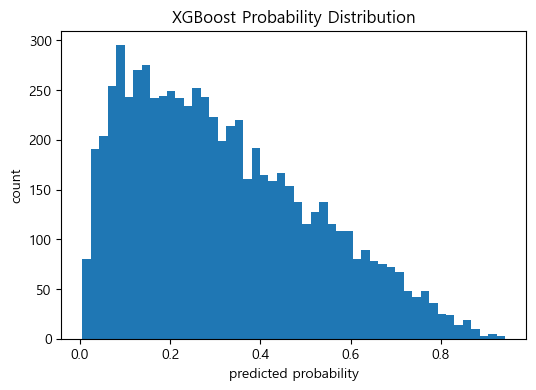

In [18]:
proba = xgb.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
plt.hist(proba, bins=50)
plt.title("XGBoost Probability Distribution")
plt.xlabel("predicted probability")
plt.ylabel("count")
plt.show()

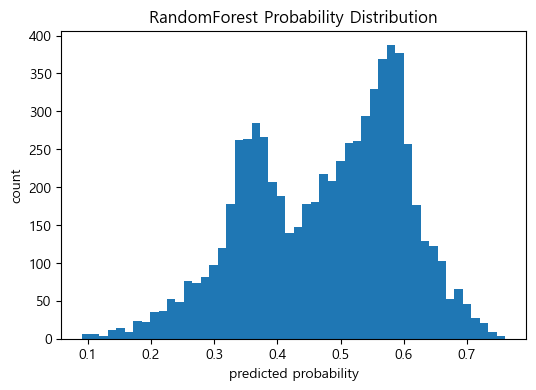

In [19]:
proba = rf.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
plt.hist(proba, bins=50)
plt.title("RandomForest Probability Distribution")
plt.xlabel("predicted probability")
plt.ylabel("count")
plt.show()

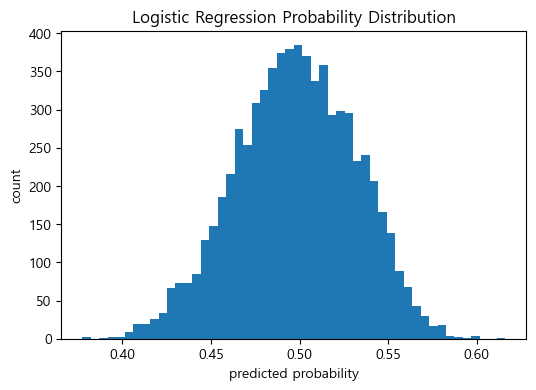

In [20]:
proba = lr.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,4))
plt.hist(proba, bins=50)
plt.title("Logistic Regression Probability Distribution")
plt.xlabel("predicted probability")
plt.ylabel("count")
plt.show()